## Brain Tumor Detection Using Transfer Learning, VGG16 model, CNN (DEEP LEARNING)

### `Importing Dependencies`

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

I0000 00:00:1784122781.336757   32025 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784122781.362448   32025 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784122782.078063   32025 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

2.21.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### `Loading Datasets`

In [4]:
train_dir = "dataset/data/Training"
test_dir = "dataset/data/Testing"

train_paths = []
train_labels = []

for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append((os.path.join(train_dir, label, image)))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

test_paths = []
test_labels = []

for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append((os.path.join(test_dir, label, image)))
        test_labels.append(label)
test_paths, test_labels = shuffle(test_paths, test_labels)

### `Data Visualization`

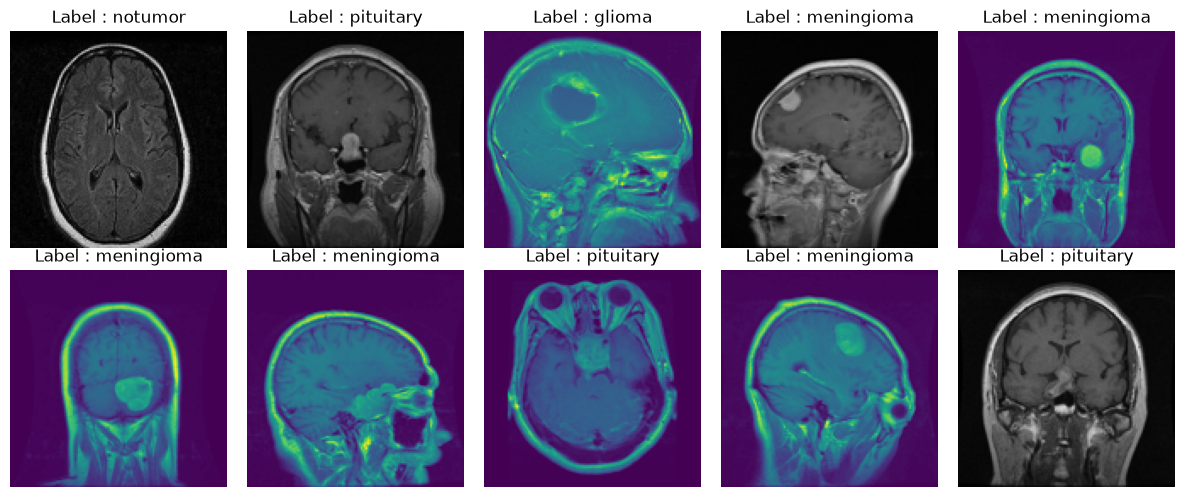

In [5]:
random_indices = random.sample(range(len(train_paths)), 10)

fig, axes = plt.subplots(2, 5, figsize = (12,5))
axes = axes.ravel()

for i, idex in enumerate(random_indices):
    img_path = train_paths[idex]
    img = Image.open(img_path)
    img = img.resize((128,128))

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Label : {train_labels[idex]}")

plt.tight_layout()
plt.show()

### `Image Preprocessing`

In [6]:
def augement_image(image):
    pass

def open_images(image):
    pass

def encode_labels(labels):
    pass

def data_generator(paths, labels, batch_size=12, epochs=1):
    pass

### `Model Architechture`

In [ ]:
Image_SIZE = 128
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(Image_SIZE, Image_SIZE,3))

for layer in base_model.layers:
    layer.trainable=False

base_model.layers[-2].trainable = False
base_model.layers[-3].trainable = False
base_model.layers[-4].trainable = False

model = Sequential()
model.add(Input(shape = (Image_SIZE, Image_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss = 'sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

batch_size = 20
steps = int(len(train_paths)/batch_size)
epochs=10

history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    steps_per_epochs=steps
)